In [85]:
%load_ext autoreload  
%autoreload 2  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [86]:
# Import the Data class from the ocpy library to handle observational data.
from ocpy.data import Data

# Read the dataset from the "ny_vir.xlsx" Excel file.
# The file is expected to contain columns for Time (BJD), O-C values, and Errors.
data = Data.from_file("ny_vir.xlsx")

# Calculate weights for the observations based on their errors (1/sigma^2).
data = data.calculate_weights()

(<Axes: ylabel='O−C'>, <Axes: xlabel='Cycle', ylabel='Resid'>)

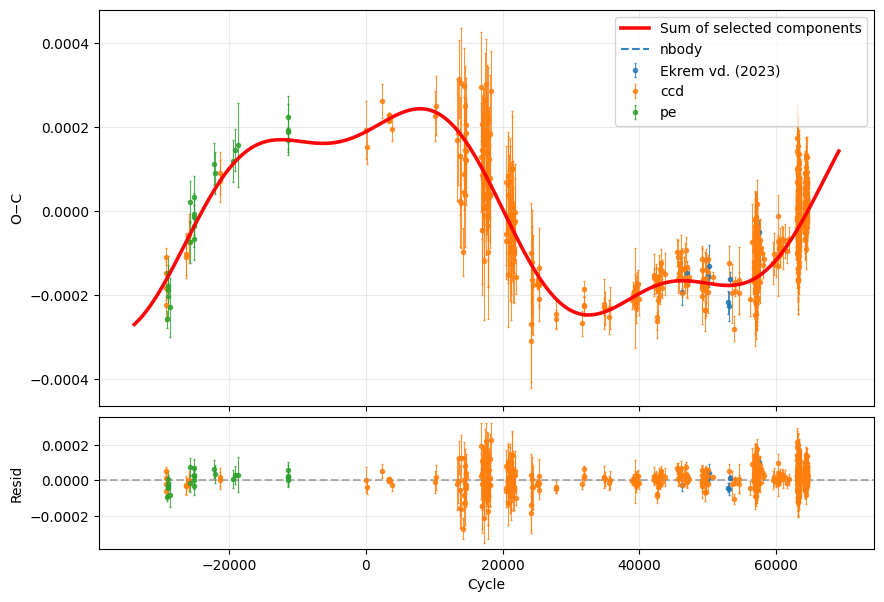

In [87]:
from ocpy.newtonian import NewtonianModel
from ocpy.oc import Parameter
import numpy as np
# Referans Zaman ve Periyot (Görselden güncellendi)
T0_ref = 2453174.442769
P_ref = 0.1010159690
nbody = NewtonianModel(
    central_mass = Parameter(value=0.471 + 0.14, fixed=True), # Mps + Mns ≈ 0.611
    T0_ref = T0_ref,
    P_ref = P_ref,
    bodies = [
        # 1. Cisim (Value 1: P=3195, M=2.283 Mjup)
        {
            "m": Parameter(value=2.283 * 0.000954588, fixed=False), # 2.283 Mjup -> Msun
            "P": Parameter(value=3195.0, fixed=False), 
            "e": Parameter(value=0.0, fixed=True), # e=0 (Görselde belirtilmiş)
            "omega": Parameter(value=0.0, fixed=True), # w=0 (Görselde belirtilmiş)
            "T": Parameter(value=2453619.0, fixed=False), # T_peri (BJD)
        },
        # 2. Cisim (Value 2: P=8404, M=3.996 Mjup)
        {
            "m": Parameter(value=3.996 * 0.000954588, fixed=False), # 3.996 Mjup -> Msun
            "P": Parameter(value=8404.0, fixed=False), 
            "e": Parameter(value=0.0, fixed=True), # e=0
            "omega": Parameter(value=0.0, fixed=True), # w=0
            "T": Parameter(value=2451010.0, fixed=False), # T_peri (BJD)
        }
    ],
    name="nbody"
)
# Not: 'data.calculate_oc' fonksiyonu ocpy.data modülünde bulunmadığı için
# burada hata alabilirsiniz. Ancak istediğiniz formatı (kendi Data objeniz tanımlıysa) koruyorum.
oc = data.calculate_oc(T0_ref, P_ref)
oc.plot(model=[nbody])

In [90]:
res = oc.fit([nbody])

In [91]:
res

(<Axes: ylabel='O−C'>, <Axes: xlabel='Cycle', ylabel='Resid'>)

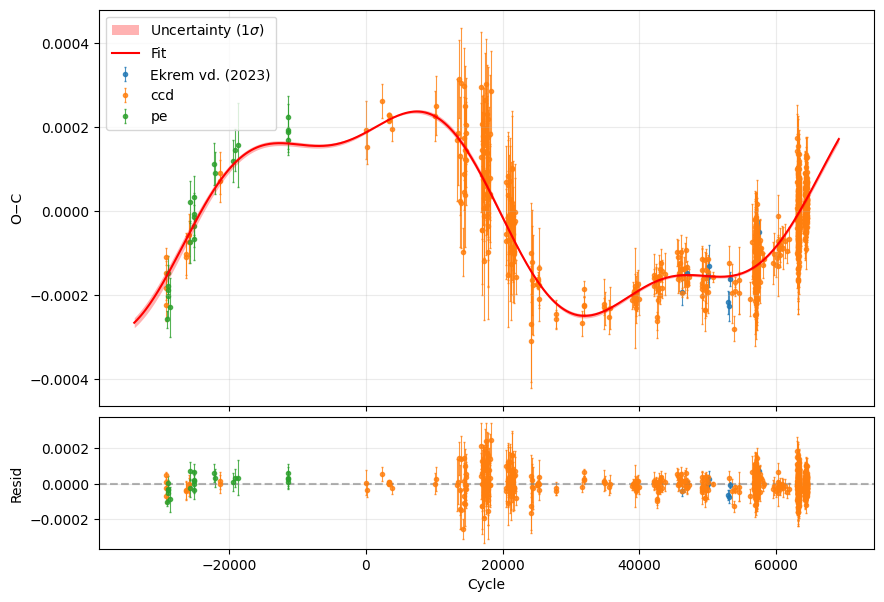

In [89]:
oc.plot(model=res)